In [9]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
study = optuna.load_study(
    storage=r"sqlite:///../../results/exploratory/1000_optuna/pre_infer.sqlite3",
    study_name="resnet_50_64img_1pls_2sample_pre_infer_fullZ_all",
)

SCALE = 8

In [11]:
df = study.trials_dataframe()
df = df[df.state == "COMPLETE"]
df.to_csv("../../results/exploratory/1000_optuna/data.csv",index=False)

In [12]:
df_failed = df[df.value == 0.825]
df_unchanged = df[df.value == 0.6875]
df_one = df[df.value == 0.671875]
df_success = df[df.value < 0.4]

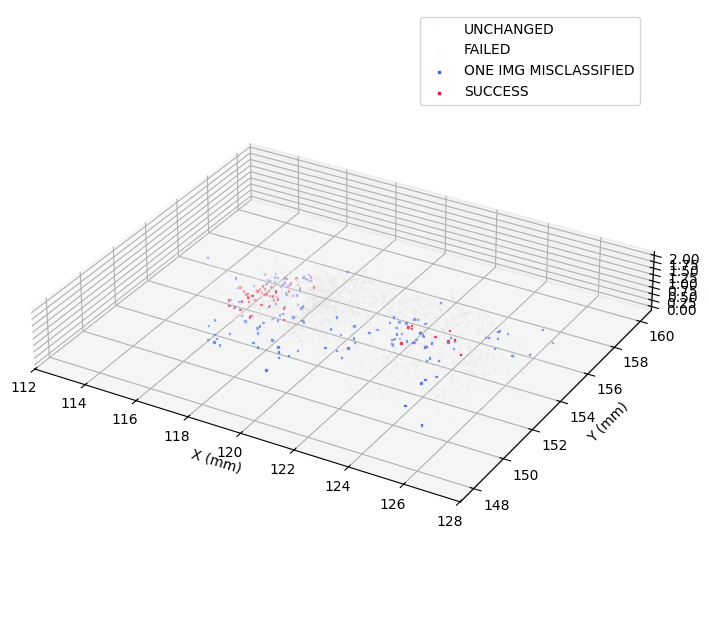

In [13]:
fig = plt.figure(figsize=(SCALE, SCALE))
ax = fig.add_subplot(111, projection="3d")

x_range = df["params_x"].max() - df["params_x"].min()
y_range = df["params_y"].max() - df["params_y"].min()
z_range = df["params_z"].max() - df["params_z"].min()

ax.set_box_aspect((x_range, y_range, z_range))

ax.scatter(
    df_unchanged["params_x"],
    df_unchanged["params_y"],
    df_unchanged["params_z"],
    c="whitesmoke",
    label="UNCHANGED",
    s=1,
    marker="s",
    alpha=0.1,
)

ax.scatter(
    df_failed["params_x"],
    df_failed["params_y"],
    df_failed["params_z"],
    c="gainsboro",
    label="FAILED",
    s=1,
    marker="s",
    alpha=0.1,
)

ax.scatter(
    df_one["params_x"],
    df_one["params_y"],
    df_one["params_z"],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=1,
    marker="s",
)

ax.scatter(
    df_success["params_x"],
    df_success["params_y"],
    df_success["params_z"],
    c="crimson",
    label="SUCCESS",
    s=1,
    marker="s",
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.legend()

# plt.savefig("../../results/exploratory/1000_optuna/3d.svg")

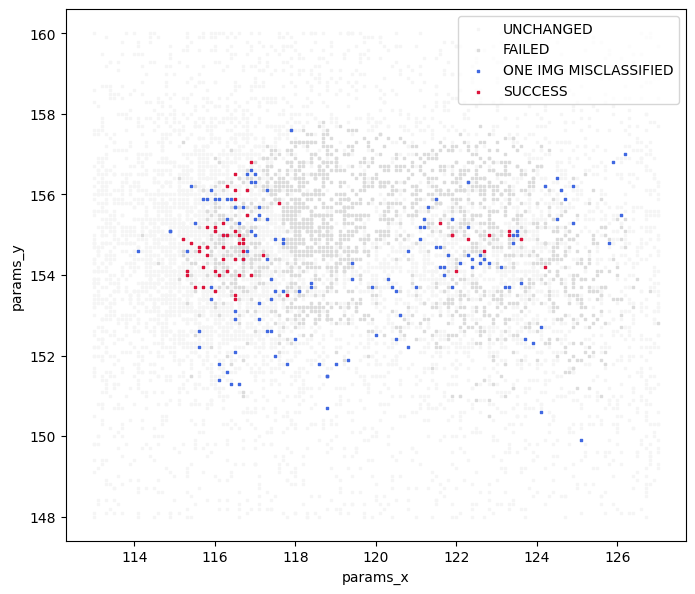

In [14]:
fig, ax = plt.subplots(figsize=(SCALE, SCALE))

ax.set_aspect("equal")

param_x = "params_x"
param_y = "params_y"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=1,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=1,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=1,
    marker="s",
)
ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=1,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

# plt.savefig("../../results/exploratory/1000_optuna/2d.svg")
plt.savefig("../../results/exploratory/1000_optuna/2d_2.svg")

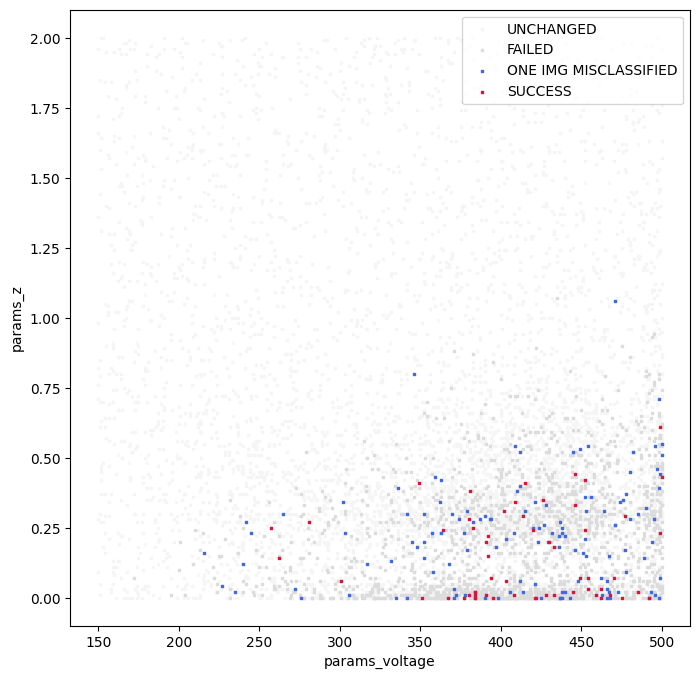

In [15]:
fig, ax = plt.subplots(figsize=(SCALE, SCALE))

# ax.set_aspect("equal")

param_x = "params_voltage"
param_y = "params_z"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=1,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=1,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=1,
    marker="s",
)
ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=1,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

# plt.savefig("../../results/exploratory/1000_optuna/z_vs_voltage.svg")
plt.savefig("../../results/exploratory/1000_optuna/z_vs_voltage_2.svg")

In [16]:
df.describe()

,number,value,datetime_start,datetime_complete,duration,params_voltage,params_width,params_x,params_y,params_z
count,8335.000000,8335.000000,8335,8335,8335,8335.000000,8335.000000,8335.000000,8335.000000,8335.000000
mean,4169.277265,0.711163,2026-04-05 18:35:06.121766,2026-04-05 18:35:18.255312,0 days 00:00:12.133545,375.431434,1.584043,119.090306,154.420936,0.478930
min,0.000000,0.000000,2026-04-04 18:42:20.290487,2026-04-04 18:42:28.466015,0 days 00:00:04.843010,150.000000,1.000000,113.000000,148.000000,0.000000
25%,2083.500000,0.687500,2026-04-05 00:53:07.088129,2026-04-05 00:53:14.186667,0 days 00:00:06.771591,322.500000,1.000000,116.000000,153.100000,0.120000
50%,4168.000000,0.687500,2026-04-05 15:01:55.566104,2026-04-05 15:02:02.195373,0 days 00:00:07.113965,394.000000,1.000000,118.200000,154.500000,0.330000
75%,6255.500000,0.687500,2026-04-06 18:23:05.287013,2026-04-06 18:23:26.154506,0 days 00:00:07.782047,442.000000,2.000000,122.200000,155.900000,0.630000
max,8341.000000,0.825000,2026-04-07 01:46:47.197596,2026-04-07 01:46:53.802550,0 days 00:01:43.410444,500.000000,3.000000,127.000000,160.000000,2.000000
std,2408.683152,0.080809,NaN,NaN,0 days 00:00:10.804257,87.334893,0.723204,3.740573,2.355310,0.486699
